In [1]:
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, ProgressBarCallback, CallbackList
import matplotlib.pyplot as plt
import numpy as np
import time
import pyautogui
import mss
import cv2
from collections import deque

2025-01-07 16:39:50.527249: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-07 16:39:50.534972: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736260790.544580 2251675 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736260790.547440 2251675 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-07 16:39:50.557695: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# визначеня області яку будемо захоплювати

In [2]:
# колбек для обробки подій миші
def draw_rectangle(event, x, y, coords):
        
    if event == cv2.EVENT_LBUTTONDOWN:
        coords = [(x, y)]
    elif event == cv2.EVENT_LBUTTONUP:
        coords.append((x, y)) 


In [3]:
def get_screen() -> np.array:
    with mss.mss() as sct:
        monitor = sct.monitors[1]
        screenshot = sct.grab(monitor)
        screen_np = np.array(screenshot)
    return screen_np

In [4]:
def get_capture_area():
    time.sleep(5)  # щоб втигнути перемкнутись на потрібнне вікно
    coords = []
    screen_np = get_screen()
    # виводимо скріншот всього екрану та очікуємо на 2 кліка микшкою: верхній лівий та нижній поавий кути області уваги
    cv2.imshow("area", screen_np)
    cv2.setMouseCallback("area", lambda event, x, y, *args: draw_rectangle(event, x, y, coords))

    # очікуємо поки у нас не буде двох координат
    while len(coords) < 2:
        if cv2.waitKey(1) & len(coords) == 2:
            cv2.destroyAllWindows()
            break

    cv2.destroyAllWindows()

    # приводимо координати до зручного нам формату
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    top = min(y1, y2)
    left = min(x1, x2)
    width = abs(x2 - x1)
    height = abs(y2 - y1)

    return {"top": top, "left": left, "width": width, "height": height}

In [6]:
# cords = get_capture_area()
cords = {'top': 192, 'left': 1160, 'width': 599, 'height': 149} # щоб постійно не обирати координати
cords

{'top': 192, 'left': 1160, 'width': 599, 'height': 149}

In [7]:
import pytesseract

In [23]:
class DinoEnv(gym.Env): 
    # середовищє немає фіксованої довжини. Скільки дінозаврик напригає - стільки він і молодець. 
    #Якщо додати можливість роботи після зміни фону - це зробить задачу щє цікавішою
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, area=None, render_mode=None):
        super(DinoEnv, self).__init__()

        self.obs_shape = (200, 50, 1)
        self.action_space = spaces.Discrete(2) # простір дій. ми можемо виконувати діскретні 2 дії: стрибати та нічого не робити   
        self.observation_space = spaces.Box(low=0, high=255, shape=(self.obs_shape[1], self.obs_shape[0], self.obs_shape[2]), dtype=np.uint8) # простір спостережень. У якості спостереження ми повертатимо зображення в градаціях сірого
        
        # координати зони уваги на моніторі
        if area is None:
            self.game_area = get_capture_area()
        else:
            self.game_area = area

        self.warmup = 26  # у моєму випадку приблизно стільки кроків має відбутись щоб з'явились перешкоди. Додамо штраф за стрибки, коли не видно перешкод на основі цієї змінної
        self.render_mode = render_mode
        self.done = False
        self.current_frame = None
        self.raw_frame = None  
        self.timesteps = 0

    

    # def _check_game_over(self):
    #     # спочатку була ідея написати просту модель класифікації щоб відрязняти кадр з написом GAME OVER, але це трохи оверкіл
    #     # просто будемо порівнювати поточний фрейм з попереднім. Якщо вони еквівалентні - гра зупинилась, ми програли
    #     if self.raw_frame is None or self.current_frame is None or len(self.prev_frames) < 4: # для першого кадру
    #         return False     
    #     # if np.array_equal(self.current_frame, self.prev_frame):     
    #     #     print(np.array_equal(self.current_frame, self.prev_frame))
    #     # print (np.array_equal(self.prev_frames[0], self.prev_frames[1]) and np.array_equal(self.prev_frames[0], self.prev_frames[2]))
    #     return np.array_equal(self.prev_frames[0], self.prev_frames[1]) and np.array_equal(self.prev_frames[0], self.prev_frames[2]) and np.array_equal(self.prev_frames[0], self.prev_frames[3])

    # UPD: терія не спрацювала - було дуже банато хибних спрацювань механізму коли кактуси були відсутні, тож будемо детектувати текст GAME OVER


    def _check_game_over(self):

        if self.raw_frame is None or self.timesteps < self.warmup:  # для першого кадру, а також врахуємо затримку надпису GAME OVER при перезапуску гри
            return False
        
        # як виявилось у гри в кінці фон змінює свій колір на білий (в мене чорна тема), надписів не виникає, тож для перезапуску ми будемо брати середнє значення кадру, 
        # перевіряти чи не став кадр глобально світлішим. Якщо став - перезапускати гру далі.
        
        # Якщо середнє значення пікселів більше 250 (екран майже білий), гра завершена
        mean_pixel_value = np.mean(self.raw_frame)
        # print(mean_pixel_value)
        
        if mean_pixel_value > 70:  # середнє значення пікселів у моєму випадку складає 35-40 при грі.
            print("гра пройдена!")
            pyautogui.press("space")
            return False

            # UPD: зміна фону - це не кінець гри, але вже не будемо це обробляти, так як модель і так навчалась 17 годин і наша задача не пройти гру а попрацювати з середовищєм та RL
        
        _, binary_frame = cv2.threshold(self.raw_frame, 128, 255, cv2.THRESH_BINARY)

        # для кращої оптимізації можна було б дивитись не на весь кадр, а тільки на область, де виникає надпис
        text = pytesseract.image_to_string(binary_frame, lang="eng")

        if "GAME OVER" in text.upper():
            # print("reset!!!")
            return True
        return False
    
    def step(self, action):
        foul = 0
        
        if action == 1:
            pyautogui.keyDown("space")
            pyautogui.keyUp("space")
            # print("jump")
        
        if action == 1 and self.timesteps <= self.warmup:  # по-хорошему це потрібно було б реалізувати у функції _calculate_reward, 
                                                    #але відчуваю, що просто передати туди аргумент - викличе якісь помилки, які потрібно буде вирішувати, а це знов не зовсім наша мета
            foul = -1
        
        obs = self._get_observation()
        self.timesteps += 1
        # if self.timesteps == 0:
            # print("timesteps")
        self.done = self._check_game_over()
        reward = self._calculate_reward() + foul  # додаємо штраф за стрибки коли кактусів немає
        # print(reward)                            
        if self.render_mode == "human":
            self.render()

        return obs, reward, self.done, {}                             
    
    def reset(self):
        # print("reset")
        pyautogui.press("space")
        # time.sleep(1)  # оце призводить до неочікуваних результатів. Кращє рахувати кроки
        self.done = False
        self.timesteps = 0
        self.raw_frame = None
        
        if self.render_mode == "human":
            cv2.destroyAllWindows()

        return self._get_observation()
    
    def render(self):
        if self.current_frame is not None:
            cv2.imshow("DinoEnv", self.current_frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                self.close()

    def close(self):
        if self.render:
            cv2.destroyWindow("DinoEnv")

    def _get_observation(self):
        screen = get_screen() # я знаю, що так - це мовітон, але нащо плодити однакові рядки
            
        frame = screen[self.game_area['top']:self.game_area['top'] + self.game_area['height'],
                       self.game_area['left']:self.game_area['left'] + self.game_area['width']]
        
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        self.raw_frame = frame.copy()  # це для обробки текстів
        frame = cv2.resize(frame, self.obs_shape[:2])
        
        frame = frame[..., np.newaxis]  # додання каналу
        # print(frame.shape)
        self.current_frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)  # у кольорове обратно для рендеру
    
        return frame
    
    def _calculate_reward(self):

        # if self.timesteps <= self.warmup:
        #     return 0
        # elif self.timesteps and self.timesteps % 100 == 0:
        #     self.timesteps = 100
        #     return 200
        return 1

In [9]:
dino_env = DinoEnv(cords)

In [10]:
eval_dino_env = DinoEnv(cords)

In [11]:
class RewardPlotCallback(BaseCallback):
    def __init__(self, output_file="rewards.png", freq=10):
        super(RewardPlotCallback, self).__init__()
        self.episode_rewards = []  # Список для збереження очок кожного епізоду
        self.output_file = output_file  # Шлях до файлу для збереження графіка
        self.current_episode_reward = 0  # Поточна винагорода за епізод

    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals["rewards"][0]

        if self.locals["dones"][0]:
            # додаємо повну винагороду за епізод до списку
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0  # скидаємо поточну винагороду
            self.plot_rewards()

        return True

    def plot_rewards(self):
        plt.figure(figsize=(15, 6))
        plt.plot(self.episode_rewards, label="reward per episode", color="blue")

        # лінія тренду, для розуміння того, чи є сенс навчати далі
        if len(self.episode_rewards) > 1:
            x = np.arange(len(self.episode_rewards))
            z = np.polyfit(x, self.episode_rewards, 1)  # Лінія тренду першого ступеня
            p = np.poly1d(z)
            plt.plot(x, p(x), label="trend", color="red", linestyle="--")

        plt.xlabel("episode")
        plt.ylabel("reward")
        plt.legend()
        plt.grid()

        plt.savefig(self.output_file)
        plt.close()


In [12]:

eval_callback = EvalCallback(eval_dino_env , best_model_save_path="./logs_dino/",
                             log_path="./logs_dino/", eval_freq=3840,
                             deterministic=True, render=False, n_eval_episodes=5, verbose=1)


plot_callback = RewardPlotCallback()

/home/pivden/hilel_machine_learning/hilel_machine_learning/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [13]:
callbacks = CallbackList([plot_callback, eval_callback])

In [14]:
model = PPO("CnnPolicy", dino_env, n_steps=1024, verbose=0, learning_rate=2e-4, ent_coef=0.02, batch_size=32)
# трохи скрутимо коефіцієнт ентропії, (на графіку нижче - 0.1 через що він досить хаотичний), 
# для того щоб залишити можливість експерементувати, але віддавати перевагу надійним стратегіям

/home/pivden/hilel_machine_learning/hilel_machine_learning/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [ ]:
model.learn(total_timesteps=512000, progress_bar=True, callback=eval_callback)

# прибрав логування за 17 годин для читабельності

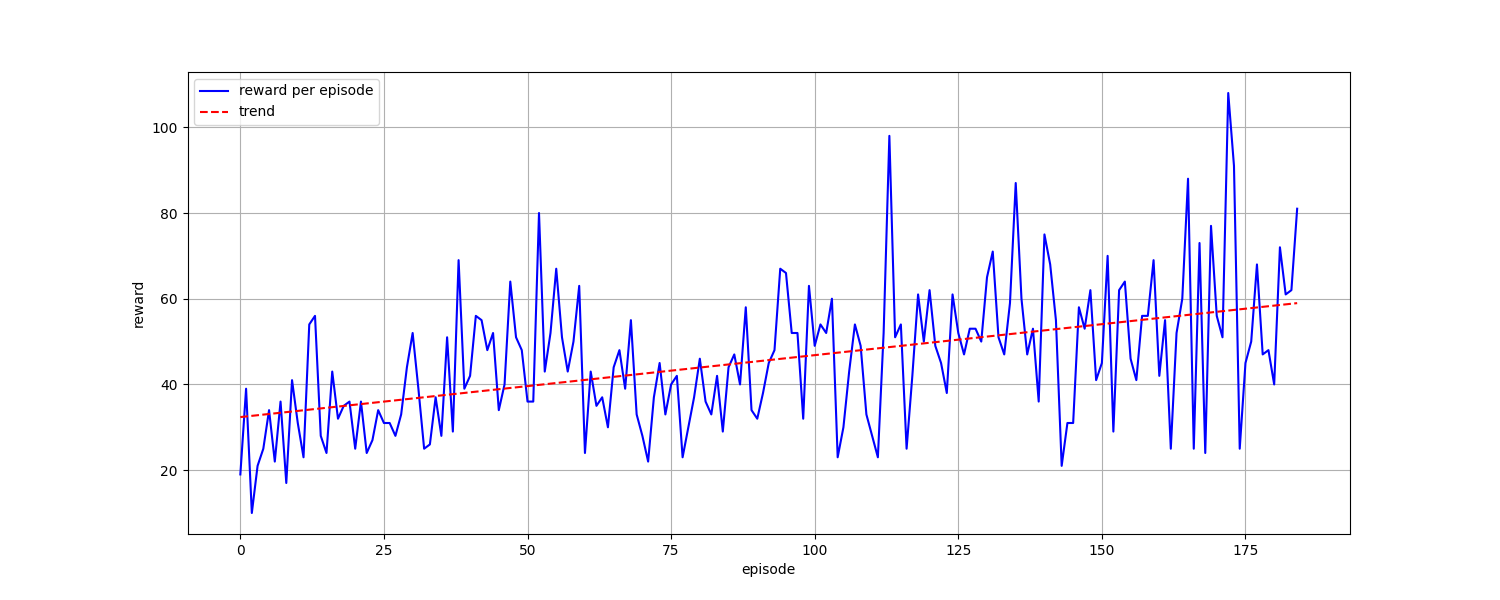 

Бачимо, що наша модель почала стабільно навчатись. 1 раз навіть дійшла до птахів. Іноді є хибні спрацювання reset на вищіх ітераціях, але це скоріш за все пов'язано із нашим калбеком для збереження графіка:
так як він працює зі списками, просто надтодовгі списки приторможують виконання. Вцілому механізм визначення завершення гри не ідеальний, але показує хороші результати, в порівнянні еквівалентнісю кадрів. Спробуємо навчити модель на більшій кількості кроків та відключимо калбек для графіку

UPD: ділий екран - то не кінець гри, а просто чомусь гра міняє фон і не виводить GAMEOVER при програші. Але вже це обробляти і перенавчати агента не будемо.
UPD: крайня краща модель була збережена 4 години тому, тож примусово зупинемо навчання.

In [15]:
def eval_agent(env, model):  # трохи модифікували нашу функцію для роботи з нашим середовищєм
    obs = env.reset() 
    # print(obs)
    # obs = np.transpose(obs, (2, 0, 1))
    
    for _ in range(2000):
        # env.render() # рендерінг нам не потрібен, бо агент буде грати у реальному часі
        action, _states = model.predict(obs) 
        result = env.step(action)
        obs, reward, done, info = result

        if done:
            obs = env.reset()

    env.close()

In [16]:
dino_model = PPO.load("logs_dino/best_model.zip")

In [21]:
dino_env = DinoEnv(cords)

In [ ]:
time.sleep(2)
eval_agent(dino_env, dino_model)

Цікава домашка! Вже підібрав собі курс по Unity щоб створювати більш складні середовища. 

Вцілому все працює. Баги відомі, але їх виправлення займе досить багато часу, в основному завдяки тому що наш агент може навчатись лише в один поток, так як він фактично грає в гру. Самий важоливий урок з конкретно цього міні-проекту - це потрібно максимально приділяти увагу тому за що штрафуємо і за що даємо винагороду, ідентифікувати коли грра пройдена. коли програна. Саме через невірну ідентифікацію програшу я витратив 2 дні на навчання агента, який просто і далі рандомно виконував дії. І тільки після того як я відобразив графік винагород із трендом - я став реально розуміти чи є система винагород і гіперпараметри навчання дієвими, виконуючи досить короткі навчання.